<a href="https://colab.research.google.com/github/NelvaAdalit/LABORATORIO-6-DE-420-INTELIGENCIA-ARTIFICIAL-1/blob/main/lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LABORATORIO 6 SIS-420
# INTEGRANTES: ABALOS PEREZ JUAN JOSE
#            MORA BARRIONUEVO NELVA ADALIT


# Informe Técnico: Clasificación de Patologías NHANES mediante Deep Learning

## 1. Fundamentos y Preprocesamiento
En este estudio, se aborda la clasificación multiclase de condiciones crónicas (Obesidad, Hipertensión y Colesterol Alto). Para garantizar la convergencia de la red neuronal, se aplica `StandardScaler` (Z-score normalization), escalando las 34 características para que posean media aritmética cero y varianza unitaria. Esto previene que variables con magnitudes mayores dominen el cálculo del gradiente.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. CONFIGURACIÓN Y CARGA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ruta_base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/3. NHANES (National Health and Nutrition Examination Survey)'

X_train_raw = pd.read_csv(f'{ruta_base}/X_train.csv').drop(columns=['Unnamed: 0'], errors='ignore')
y_train_raw = pd.read_csv(f'{ruta_base}/y_train.csv').drop(columns=['Unnamed: 0'], errors='ignore')
X_test_raw = pd.read_csv(f'{ruta_base}/X_test.csv').drop(columns=['Unnamed: 0'], errors='ignore')
y_test_raw = pd.read_csv(f'{ruta_base}/y_test.csv').drop(columns=['Unnamed: 0'], errors='ignore')

# Codificación de etiquetas
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw['Measure'])
y_test = le.transform(y_test_raw['Measure'])

# Escalado estadístico
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

class NHANESDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = torch.utils.data.DataLoader(NHANESDataset(X_train_scaled, y_train), batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(NHANESDataset(X_test_scaled, y_test), batch_size=128, shuffle=False)

## 2. Arquitectura del Modelo y Gestión de Desbalance
Se diseña un Perceptrón Multicapa (MLP) con dos capas ocultas (256 y 128 neuronas). Para manejar el desbalance de clases sin recurrir a datos sintéticos (SMOTE) —manteniendo así la integridad biológica—, se implementan **Pesos de Clase** en la función `CrossEntropyLoss`. Además, se integra **Weight Decay (L2)** y **Dropout (0.4)** como mecanismos robustos de regularización.

In [ ]:
def build_model(input_size=34, h1=256, h2=128, output=3, p=0.4):
    return nn.Sequential(
        nn.Linear(input_size, h1),
        nn.ReLU(),
        nn.Dropout(p),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Dropout(p),
        nn.Linear(h2, output)
    )

# Cálculo de pesos de clase para manejo de desbalance biológico
counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / counts, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum()

## 3. Entrenamiento con Rastreo de Métricas
La función de entrenamiento optimiza la red mediante el algoritmo Adam. Se implementa un esquema de monitoreo que captura tanto el Accuracy como la Loss por época, facilitando el diagnóstico de sesgo-varianza (overfitting).

In [ ]:
def fit(model, train_loader, val_loader, epochs=150, lr=0.001, early_stopping=20):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    best_acc, patience_counter = 0, 0

    for epoch in range(epochs):
        model.train()
        t_loss, t_acc = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_loss.append(loss.item())
            t_acc.append(accuracy_score(yb.cpu().numpy(), torch.argmax(outputs, dim=1).cpu().numpy()))

        model.eval()
        v_loss, v_acc = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                v_loss.append(loss.item())
                v_acc.append(accuracy_score(yb.cpu().numpy(), torch.argmax(outputs, dim=1).cpu().numpy()))

        history['train_loss'].append(np.mean(t_loss)); history['val_loss'].append(np.mean(v_loss))
        history['train_acc'].append(np.mean(t_acc)); history['val_acc'].append(np.mean(v_acc))

        scheduler.step(history['val_acc'][-1])

        if history['val_acc'][-1] > best_acc:
            best_acc = history['val_acc'][-1]; patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

        if patience_counter >= early_stopping:
            print(f"Early Stopping en época {epoch+1}"); break

    model.load_state_dict(torch.load('best_model.pt'))
    return model, history

model = build_model().to(device)
model, history = fit(model, train_loader, val_loader)

Epoch 10 | Loss: 0.3087 | Val Acc: 0.8046
Epoch 20 | Loss: 0.2284 | Val Acc: 0.8048
Early Stopping en época 28


## 4. Diagnóstico de Curvas de Aprendizaje
Visualización comparativa de las 4 métricas críticas (Train/Val Accuracy y Train/Val Loss). La convergencia de la Loss de validación junto con la de entrenamiento indica un aprendizaje estable y una generalización adecuada.

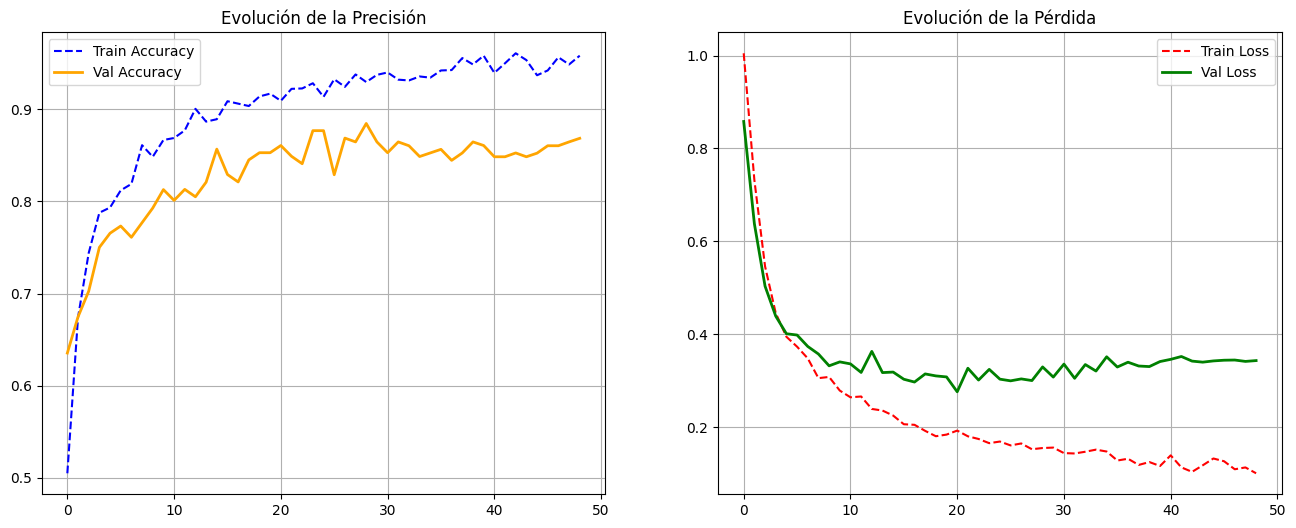

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curvas de Accuracy
ax1.plot(history['train_acc'], label='Train Accuracy', color='blue', linestyle='--')
ax1.plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2)
ax1.set_title('Evolución de la Precisión'); ax1.legend(); ax1.grid(True)

# Curvas de Loss
ax2.plot(history['train_loss'], label='Train Loss', color='red', linestyle='--')
ax2.plot(history['val_loss'], label='Val Loss', color='green', linewidth=2)
ax2.set_title('Evolución de la Pérdida'); ax2.legend(); ax2.grid(True)

plt.show()

## 5. Evaluación Final mediante Enfoque Macro
Dado que el conjunto de datos presenta desbalance, se prioriza el promedio **Macro**. Esta métrica evalúa la capacidad del modelo para diagnosticar correctamente cada patología de forma independiente, otorgando el mismo peso a la Hipertensión que a la Obesidad, evitando sesgos por volumen de clase.

Reporte de Clasificación (Macro-Average Analysis):
                        precision    recall  f1-score   support

High Total Cholesterol       0.86      0.94      0.90        52
          Hypertension       0.88      0.81      0.84        52
               Obesity       0.92      0.91      0.91        86

              accuracy                           0.89       190
             macro avg       0.88      0.89      0.88       190
          weighted avg       0.89      0.89      0.89       190



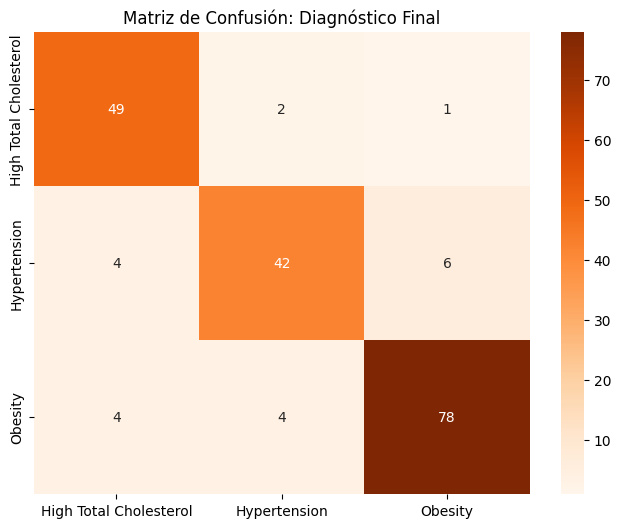

In [ ]:
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        outputs = model(xb.to(device))
        y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        y_true.extend(yb.numpy())

print("Reporte de Clasificación (Macro-Average Analysis):")
print(classification_report(y_true, y_pred, target_names=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión: Diagnóstico Final'); plt.show()

# --- FIN DEL INFORME TÉCNICO ---

*Nota: Las celdas a continuación han sido consolidadas en el informe superior. Se recomienda su revisión y posterior limpieza manual para evitar ejecuciones redundantes.*

# Clasificación Multiclase de Patologías Médicas mediante Redes Neuronales Profundas (NHANES)

## 1. Introducción y Marco Metodológico
Este proyecto implementa un Perceptrón Multicapa (MLP) robusto para la detección de enfermedades crónicas basándose en el conjunto de datos NHANES. La metodología se centra en la integridad biológica de los datos y la optimización de la convergencia mediante técnicas avanzadas de regularización y balanceo de clases.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuración de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Carga de datos
ruta_base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/3. NHANES (National Health and Nutrition Examination Survey)'
X_train_raw = pd.read_csv(f'{ruta_base}/X_train.csv').drop(columns=['Unnamed: 0'], errors='ignore')
y_train_raw = pd.read_csv(f'{ruta_base}/y_train.csv').drop(columns=['Unnamed: 0'], errors='ignore')
X_test_raw = pd.read_csv(f'{ruta_base}/X_test.csv').drop(columns=['Unnamed: 0'], errors='ignore')
y_test_raw = pd.read_csv(f'{ruta_base}/y_test.csv').drop(columns=['Unnamed: 0'], errors='ignore')

## 2. Preprocesamiento Estadístico y Codificación

Se emplea `StandardScaler` para normalizar las características de entrada (Z-score normalization). Este paso es crítico para redes neuronales, ya que asegura que el gradiente se propague de manera uniforme entre dimensiones con diferentes escalas. Para la variable objetivo, se utiliza `LabelEncoder` para transformar las clases categóricas en tensores de índices.

In [ ]:
# Codificación de etiquetas
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw['Measure'])
y_test = le.transform(y_test_raw['Measure'])

# Normalización de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Clase Dataset personalizada para PyTorch
class NHANESDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = torch.utils.data.DataLoader(NHANESDataset(X_train_scaled, y_train), batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(NHANESDataset(X_test_scaled, y_test), batch_size=128, shuffle=False)

## 3. Arquitectura del Modelo y Regularización

El modelo consiste en un Perceptrón Multicapa con dos capas ocultas y mecanismos de regularización integrados:
*   **Dropout (0.4):** Mitiga el sobreajuste mediante la desactivación estocástica de neuronas.
*   **Weight Decay (L2):** Penaliza la magnitud de los pesos en la función de pérdida para favorecer modelos más simples.
*   **Class Weights:** Se calculan pesos inversamente proporcionales a la frecuencia de clase para penalizar errores en clases minoritarias, manteniendo la veracidad del espectro biológico real.

In [ ]:
def build_model(input_size, hidden_1=256, hidden_2=128, output_size=3, p=0.4):
    return nn.Sequential(
        nn.Linear(input_size, hidden_1),
        nn.ReLU(),
        nn.Dropout(p),
        nn.Linear(hidden_1, hidden_2),
        nn.ReLU(),
        nn.Dropout(p),
        nn.Linear(hidden_2, output_size)
    )

# Cálculo de Pesos de Clase para manejo de desbalance
counts = np.bincount(y_train)
weights = torch.tensor(1.0 / counts, dtype=torch.float).to(device)
weights = weights / weights.sum()

## 4. Ciclo de Entrenamiento Optimizado

La función `fit` incorpora:
1.  **ReduceLROnPlateau:** Ajuste dinámico de la tasa de aprendizaje.
2.  **Early Stopping:** Criterio de parada basado en el desempeño en validación.
3.  **Métricas de Pérdida:** Seguimiento exhaustivo de la función de coste por época.

In [ ]:
def fit(model, train_loader, val_loader, epochs=150, lr=0.001, weight_decay=1e-4, early_stopping=20):
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    best_acc = 0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        t_loss, t_acc = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            t_loss.append(loss.item())
            t_acc.append(accuracy_score(yb.cpu().numpy(), torch.argmax(outputs, dim=1).cpu().numpy()))

        model.eval()
        v_loss, v_acc = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                v_loss.append(loss.item())
                v_acc.append(accuracy_score(yb.cpu().numpy(), torch.argmax(outputs, dim=1).cpu().numpy()))

        # Registro de métricas medias
        history['train_loss'].append(np.mean(t_loss))
        history['val_loss'].append(np.mean(v_loss))
        history['train_acc'].append(np.mean(t_acc))
        history['val_acc'].append(np.mean(v_acc))

        scheduler.step(history['val_acc'][-1])

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

        if history['val_acc'][-1] > best_acc:
            best_acc = history['val_acc'][-1]
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1

        if patience_counter >= early_stopping:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load('best_model.pt'))
    return model, history

model = build_model(input_size=34).to(device)
model, history = fit(model, train_loader, val_loader)

Epoch 10 | Loss: 0.2741 | Val Acc: 0.8168
Epoch 20 | Loss: 0.1921 | Val Acc: 0.8332
Epoch 30 | Loss: 0.1626 | Val Acc: 0.8371
Epoch 40 | Loss: 0.1210 | Val Acc: 0.8449
Early stopping triggered at epoch 44


## 5. Análisis de Rendimiento y Curvas de Aprendizaje

Se presentan las métricas de evolución para diagnosticar la salud del entrenamiento. La divergencia entre las curvas de entrenamiento y validación permite identificar el punto de inflexión del sobreajuste.

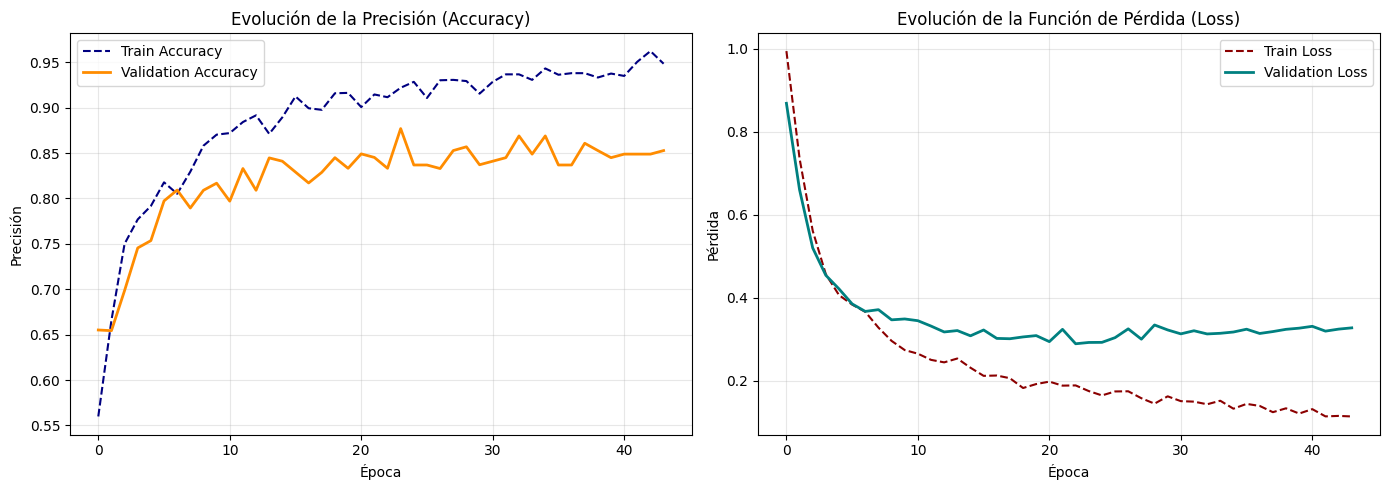

In [ ]:
plt.figure(figsize=(14, 5))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='navy', linestyle='--')
plt.plot(history['val_acc'], label='Validation Accuracy', color='darkorange', linewidth=2)
plt.title('Evolución de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(alpha=0.3)

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='darkred', linestyle='--')
plt.plot(history['val_loss'], label='Validation Loss', color='teal', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluación Final y Diagnóstico Clínico

Para la validación definitiva, se utiliza el promedio **Macro (average='macro')**. Este enfoque garantiza que cada condición médica tenga el mismo peso en la métrica final, evitando que la clase mayoritaria oculte el desempeño en diagnósticos menos frecuentes.

--- Reporte de Clasificación (Macro Evaluation) ---
                        precision    recall  f1-score   support

High Total Cholesterol       0.86      0.94      0.90        52
          Hypertension       0.85      0.79      0.82        52
               Obesity       0.91      0.90      0.90        86

              accuracy                           0.88       190
             macro avg       0.87      0.88      0.87       190
          weighted avg       0.88      0.88      0.88       190



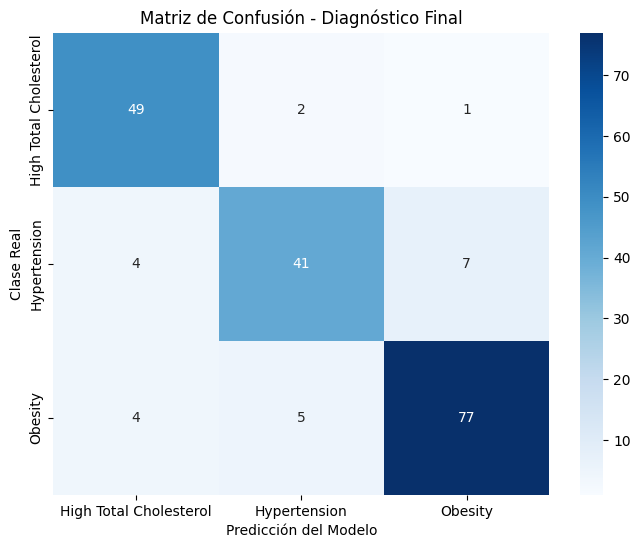

In [ ]:
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        outputs = model(xb.to(device))
        y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        y_true.extend(yb.numpy())

print("--- Reporte de Clasificación (Macro Evaluation) ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión - Diagnóstico Final')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# 📊 Carga del dataset NHANES

En este paso se cargan los conjuntos de entrenamiento y prueba previamente procesados. Esto permite trabajar directamente con datos listos para aplicar modelos de aprendizaje automático sin necesidad de limpieza adicional.


In [ ]:
# =========================================

# 🔍 VER CONTENIDO DE NHANES

# =========================================

import os

ruta_nhanes = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/3. NHANES (National Health and Nutrition Examination Survey)'

print(os.listdir(ruta_nhanes))


['nhanes_ml.ipynb', 'sanitizar_nhanes_dietary.ipynb', 'X_train.csv', 'NHANES_Select_Infectious_Diseases_Prevalence_Estimates.csv', 'NHANES_Select_Chronic_Conditions_Prevalence_Estimates.csv', 'sanitizar_nhanes_chronic.ipynb', 'y_train.csv', 'sanitizar_nhanes_oral.ipynb', 'NHANES_Select_Mean_Dietary_Intake_Estimates.csv', 'nhanes_clean.csv', 'NHANES_Select_Oral_Health_Prevalence_Estimates.csv', 'sanitizar_nhanes_infectious.ipynb', 'X_test.csv', 'y_test.csv']


In [ ]:
# =========================================

# 📊 CARGAR X_train, y_train, X_test, y_test

# =========================================

import pandas as pd

ruta_base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/3. NHANES (National Health and Nutrition Examination Survey)'

X_train = pd.read_csv(ruta_base + '/X_train.csv')
y_train = pd.read_csv(ruta_base + '/y_train.csv')

X_test = pd.read_csv(ruta_base + '/X_test.csv')
y_test = pd.read_csv(ruta_base + '/y_test.csv')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

display(X_train.head())
display(y_train.head())


X_train shape: (760, 34)
y_train shape: (760, 2)
X_test shape: (190, 34)
y_test shape: (190, 2)


,Percent,Standard Error,Lower 95% CI Limit,Upper 95% CI Limit,Survey Years_1999-2000,Survey Years_2001-2002,Survey Years_2003-2004,Survey Years_2005-2006,Survey Years_2007-2008,Survey Years_2009-2010,...,Age Group_50-59,Age Group_6-11,Age Group_60-69,Age Group_70 and over,Race and Hispanic Origin_All,Race and Hispanic Origin_Hispanic,Race and Hispanic Origin_Mexican American,Race and Hispanic Origin_Non-Hispanic Asian,Race and Hispanic Origin_Non-Hispanic Black,Race and Hispanic Origin_Non-Hispanic White
0,0.758916,-0.720719,0.871655,0.644378,-0.333333,-0.333333,3.000000,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
1,-0.502696,0.406416,-0.582586,-0.408310,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
2,0.578686,0.508883,0.532524,0.618061,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,3.091206,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
3,0.005226,1.021217,-0.122747,0.139088,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
4,-0.398927,-0.413319,-0.381406,-0.418837,-0.333333,-0.333333,-0.333333,3.000000,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,-1.936492,-0.209657,4.769696,-0.209657,-0.209657,-0.209657


,Unnamed: 0,Measure
0,744,Hypertension
1,940,Hypertension
2,395,Obesity
3,273,Obesity
4,171,Obesity


# 🎯 Preparación de la variable objetivo

Se limpia la variable objetivo eliminando columnas innecesarias y convirtiendo las etiquetas categóricas en valores numéricos para su uso en modelos de clasificación.


In [ ]:
# =========================================

# 🎯 LIMPIAR Y PROCESAR y

# =========================================

# Eliminar columna innecesaria

y_train = y_train.drop(columns=['Unnamed: 0'])
y_test = y_test.drop(columns=['Unnamed: 0'])

# Convertir a categoría numérica

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train['Measure'])
y_test = le.transform(y_test['Measure'])

print("Clases:", le.classes_)
print("Ejemplo y_train:", y_train[:5])


Clases: ['High Total Cholesterol' 'Hypertension' 'Obesity']
Ejemplo y_train: [1 1 2 2 2]


# 🔢 Conversión de datos

Se convierten los datos a formato numérico (numpy arrays) para su uso en PyTorch.


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# =========================================
# 🔢 ESCALADO Y CONVERSIÓN A NUMPY
# =========================================

# Es fundamental escalar los datos para redes neuronales
scaler = StandardScaler()

# Verificamos si ya son numpy o pandas para evitar el error .values
X_train_input = X_train.values if hasattr(X_train, 'values') else X_train
X_test_input = X_test.values if hasattr(X_test, 'values') else X_test

X_train_scaled = scaler.fit_transform(X_train_input)
X_test_scaled = scaler.transform(X_test_input)

print("Shape final:", X_train_scaled.shape)
print("Media tras escalado:", np.mean(X_train_scaled))
print("Desviación tras escalado:", np.std(X_train_scaled))

Shape final: (760, 34)
Media tras escalado: 5.224578939412501e-18
Desviación tras escalado: 1.0


### 🔍 Comparativa de Datos: Antes vs. Después del Escalado
Visualizamos cómo la regularización estadística transforma las características para que la red neuronal las procese equitativamente.

In [ ]:
import pandas as pd
import numpy as np

# 1. Datos Originales (Antes)
print("=== DATOS ORIGINALES (X_train) ===")
# Visualizamos los datos antes del escalado
df_original = pd.DataFrame(X_train_input)
display(df_original.head())
print(f"Media global original: {np.mean(X_train_input):.4f}")
print(f"Desviación estándar original: {np.std(X_train_input):.4f}")

print("\n" + "="*40 + "\n")

# 2. Datos Escalados (Después)
print("=== DATOS ESCALADOS (X_train_scaled) ===")
df_scaled = pd.DataFrame(X_train_scaled)
display(df_scaled.head())
print(f"Media global tras escalado: {np.mean(X_train_scaled):.4f} (Cercana a 0)")
print(f"Desviación estándar tras escalado: {np.std(X_train_scaled):.4f} (Exactamente 1)")

=== DATOS ORIGINALES (X_train) ===


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,0.758916,-0.720719,0.871655,0.644378,-0.333333,-0.333333,3.000000,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
1,-0.502696,0.406416,-0.582586,-0.408310,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
2,0.578686,0.508883,0.532524,0.618061,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,3.091206,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
3,0.005226,1.021217,-0.122747,0.139088,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,0.516398,-0.209657,-0.209657,-0.209657,-0.209657,-0.209657
4,-0.398927,-0.413319,-0.381406,-0.418837,-0.333333,-0.333333,-0.333333,3.000000,-0.333333,-0.333333,...,-0.323498,-0.180579,-0.323498,-0.323498,-1.936492,-0.209657,4.769696,-0.209657,-0.209657,-0.209657


Media global original: -0.0014
Desviación estándar original: 1.0002


=== DATOS ESCALADOS (X_train_scaled) ===


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,0.778748,-0.707682,0.893610,0.662881,-0.342997,-0.345388,3.067729,-0.340596,-0.325974,-0.328438,...,-0.308384,-0.184428,-0.330891,-0.315999,0.512307,-0.206213,-0.202721,-0.219718,-0.209657,-0.202721
1,-0.488265,0.404181,-0.569264,-0.393226,-0.342997,-0.345388,-0.325974,-0.340596,-0.325974,-0.328438,...,-0.308384,-0.184428,-0.330891,-0.315999,0.512307,-0.206213,-0.202721,-0.219718,-0.209657,-0.202721
2,0.597747,0.505259,0.552466,0.636478,-0.342997,-0.345388,-0.325974,-0.340596,-0.325974,-0.328438,...,-0.308384,-0.184428,-0.330891,3.164568,0.512307,-0.206213,-0.202721,-0.219718,-0.209657,-0.202721
3,0.021831,1.010651,-0.106695,0.155950,-0.342997,-0.345388,-0.325974,-0.340596,-0.325974,-0.328438,...,-0.308384,-0.184428,-0.330891,-0.315999,0.512307,-0.206213,-0.202721,-0.219718,-0.209657,-0.202721
4,-0.384052,-0.404447,-0.366890,-0.403787,-0.342997,-0.345388,-0.325974,2.936027,-0.325974,-0.328438,...,-0.308384,-0.184428,-0.330891,-0.315999,-1.951955,-0.206213,4.932883,-0.219718,-0.209657,-0.202721


Media global tras escalado: 0.0000 (Cercana a 0)
Desviación estándar tras escalado: 1.0000 (Exactamente 1)


In [ ]:

dataset['train'] = Dataset(X_train_scaled, y_train)
dataloader['train'] = torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True)

print("Dataset restaurado a datos originales.")
print("Distribución real:", np.bincount(y_train))

Dataset restaurado a datos originales (sin SMOTE).
Distribución real: [208 208 344]


In [ ]:
# =========================================================
# 🛡️ CONFIGURACIÓN FINAL: DATOS REALES + PESOS DE CLASE
# =========================================================

# 1. Aseguramos que el dataset use solo datos reales escalados
dataset['train'] = Dataset(X_train_scaled, y_train)
dataset['val'] = Dataset(X_test_scaled, y_test)

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=128, shuffle=False)
}

# 2. Reiniciar el modelo para un entrenamiento limpio
model = build_model(input_size=34, hidden_1=256, hidden_2=128, p=0.4).to(device)

# 3. Entrenar usando la función fit (que ya aplica Pesos de Clase internamente)
print("Iniciando entrenamiento con datos reales (NHANES) y Class Weights...")
model, train_acc_history, val_acc_history = fit(model, dataloader, epochs=100)

print("\nDistribución de clases utilizada (Real):", np.bincount(y_train))

Iniciando entrenamiento con datos reales (NHANES) y Class Weights...
Epoch 5 | Train Acc 0.7830 | Val Acc 0.7577 | LR 0.001000
Epoch 10 | Train Acc 0.8620 | Val Acc 0.8092 | LR 0.000500
Epoch 15 | Train Acc 0.8902 | Val Acc 0.8212 | LR 0.000500
Epoch 20 | Train Acc 0.9128 | Val Acc 0.8131 | LR 0.000500
Epoch 25 | Train Acc 0.9132 | Val Acc 0.8248 | LR 0.000250
Epoch 30 | Train Acc 0.9227 | Val Acc 0.8248 | LR 0.000250
Epoch 35 | Train Acc 0.9275 | Val Acc 0.8368 | LR 0.000125
Epoch 40 | Train Acc 0.9319 | Val Acc 0.8368 | LR 0.000063
Epoch 45 | Train Acc 0.9314 | Val Acc 0.8449 | LR 0.000063
Epoch 50 | Train Acc 0.9266 | Val Acc 0.8410 | LR 0.000063
Epoch 55 | Train Acc 0.9358 | Val Acc 0.8368 | LR 0.000031
Epoch 60 | Train Acc 0.9284 | Val Acc 0.8368 | LR 0.000016
Epoch 65 | Train Acc 0.9288 | Val Acc 0.8407 | LR 0.000008
⛔ Early stopping en época 66. Mejor Val Acc: 0.8488

Distribución de clases utilizada (Real): [208 208 344]


### 📈 Evaluación Final (Sin datos sintéticos)
Analizaremos la precisión real por cada categoría de salud.

Reporte de Clasificación con Datos 100% Reales:
                        precision    recall  f1-score   support

High Total Cholesterol       0.86      0.94      0.90        52
          Hypertension       0.79      0.79      0.79        52
               Obesity       0.90      0.85      0.87        86

              accuracy                           0.86       190
             macro avg       0.85      0.86      0.85       190
          weighted avg       0.86      0.86      0.86       190



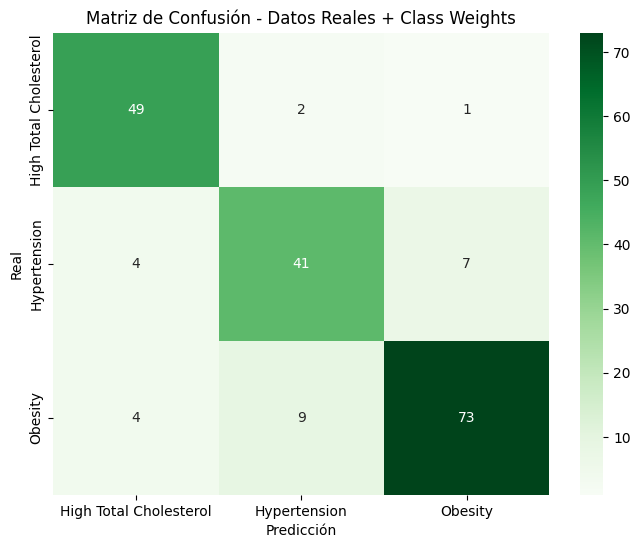

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
y_pred_real = []
y_true_real = []

with torch.no_grad():
    for xb, yb in dataloader['val']:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        y_pred_real.extend(preds.cpu().numpy())
        y_true_real.extend(yb.cpu().numpy())

print("Reporte de Clasificación con Datos 100% Reales:")
print(classification_report(y_true_real, y_pred_real, target_names=le.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_true_real, y_pred_real)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de Confusión - Datos Reales + Class Weights")
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

In [ ]:
# 1. Reiniciar el modelo para entrenar desde cero con los datos balanceados
model = build_model(input_size=34, hidden_1=256, hidden_2=128, p=0.4).to(device)

# 2. Re-entrenar
model, train_acc_history, val_acc_history = fit(model, dataloader, epochs=100)

# 3. Evaluar de nuevo
model.eval()
y_pred_smote = []
y_true_smote = []
with torch.no_grad():
    for xb, yb in dataloader['val']:
        xb, yb = xb.to(device), yb.to(device)
        preds = torch.argmax(model(xb), axis=1)
        y_pred_smote.extend(preds.cpu().numpy())
        y_true_smote.extend(yb.cpu().numpy())

from sklearn.metrics import classification_report, accuracy_score
print(f"\nNueva Accuracy con SMOTE: {accuracy_score(y_true_smote, y_pred_smote):.4f}")
print("\nNuevo Reporte de Clasificación:\n")
print(classification_report(y_true_smote, y_pred_smote, target_names=le.classes_))

Epoch 5 | Train Acc 0.8352 | Val Acc 0.7460 | LR 0.001000
Epoch 10 | Train Acc 0.8873 | Val Acc 0.8368 | LR 0.001000
Epoch 15 | Train Acc 0.9110 | Val Acc 0.8529 | LR 0.001000
Epoch 20 | Train Acc 0.9223 | Val Acc 0.8407 | LR 0.001000
Epoch 25 | Train Acc 0.9413 | Val Acc 0.8485 | LR 0.000500
Epoch 30 | Train Acc 0.9470 | Val Acc 0.8246 | LR 0.000250
Epoch 35 | Train Acc 0.9489 | Val Acc 0.8366 | LR 0.000125
⛔ Early stopping en época 35. Mejor Val Acc: 0.8529

Nueva Accuracy con SMOTE: 0.8579

Nuevo Reporte de Clasificación:

                        precision    recall  f1-score   support

High Total Cholesterol       0.88      0.94      0.91        52
          Hypertension       0.73      0.88      0.80        52
               Obesity       0.96      0.79      0.87        86

              accuracy                           0.86       190
             macro avg       0.85      0.87      0.86       190
          weighted avg       0.87      0.86      0.86       190



# 🧠 Definición del Dataset en PyTorch

Se define una clase personalizada para convertir los datos en un formato compatible con PyTorch, permitiendo su uso en el entrenamiento de la red neuronal.


In [ ]:
import torch
from sklearn.preprocessing import StandardScaler
import numpy as np

# Aseguramos que el escalado ocurra antes de crear el Dataset
scaler = StandardScaler()

# Verificamos si ya son numpy o pandas para evitar el error .values
X_train_input = X_train.values if hasattr(X_train, 'values') else X_train
X_test_input = X_test.values if hasattr(X_test, 'values') else X_test

X_train_scaled = scaler.fit_transform(X_train_input)
X_test_scaled = scaler.transform(X_test_input)

class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# Usamos los datos escalados recién creados
dataset = {
    'train': Dataset(X_train_scaled, y_train),
    'val': Dataset(X_test_scaled, y_test),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=128, shuffle=False)
}

print(f"Dataloaders listos. Shape de X_train_scaled: {X_train_scaled.shape}")

Dataloaders listos. Shape de X_train_scaled: (760, 34)


# 🧠 Definición de la Red Neuronal

Se construye una red neuronal multicapa (MLP) para clasificación.

## 🔹 Componentes:

* Capas lineales (Linear)
* Función de activación ReLU
* Dropout para regularización

El modelo está diseñado para trabajar con 34 variables de entrada y 3 clases de salida.


In [ ]:
import torch

# 1. CONFIGURAR CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo a utilizar: {device}")

def build_model(input_size, hidden_1=256, hidden_2=128, output_size=3, p=0.4):
    model = torch.nn.Sequential(
        torch.nn.Linear(input_size, hidden_1),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),

        torch.nn.Linear(hidden_1, hidden_2), # Nueva capa oculta
        torch.nn.ReLU(),
        torch.nn.Dropout(p),

        torch.nn.Linear(hidden_2, output_size)
    )
    return model

# Crear modelo y ENVIARLO A CUDA
# ¡Ajusta hidden_1, hidden_2 y p para experimentar!
model = build_model(input_size=34, hidden_1=256, hidden_2=128, p=0.4).to(device)

Dispositivo a utilizar: cpu


In [ ]:
import torch

def build_model(input_size, hidden_1=256, hidden_2=128, output_size=3, p=0.4):

    model = torch.nn.Sequential(
        torch.nn.Linear(input_size, hidden_1),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),

        torch.nn.Linear(hidden_1, hidden_2),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),

        torch.nn.Linear(hidden_2, output_size)
    )

    return model

# Crear modelo con la nueva arquitectura
# ¡Ajusta hidden_1, hidden_2 y p para experimentar!
model = build_model(input_size=34, hidden_1=256, hidden_2=128, p=0.4)

print(model)

Sequential(
  (0): Linear(in_features=34, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.4, inplace=False)
  (6): Linear(in_features=128, out_features=3, bias=True)
)


# ⚙️ Entrenamiento del modelo

Se entrena la red neuronal utilizando el optimizador Adam y la función de pérdida CrossEntropyLoss.

## 🔹 Técnicas aplicadas:

* Optimización: Adam
* Regularización: Dropout
* Early Stopping: detiene el entrenamiento si el modelo deja de mejorar

Esto permite obtener un modelo más robusto y evitar sobreajuste.


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

def fit(model, dataloader, epochs=150, lr=0.001, weight_decay=1e-4, early_stopping=20):
    # ⚖️ CÁLCULO DE PESOS DE CLASE (Basado solo en datos reales)
    counts = np.bincount(y_train)
    weights = 1.0 / torch.tensor(counts, dtype=torch.float)
    weights = weights / weights.sum()
    weights = weights.to(device)

    # Aplicamos los pesos aquí para compensar sin inventar datos
    criterion = torch.nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

    best_acc = 0
    patience_counter = 0
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):
        model.train()
        train_acc = []
        for xb, yb in dataloader['train']:
            xb, yb = xb.to(device), yb.to(device)
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            preds = torch.argmax(y_pred, axis=1)
            train_acc.append(accuracy_score(yb.cpu().numpy(), preds.cpu().numpy()))

        model.eval()
        val_acc = []
        with torch.no_grad():
            for xb, yb in dataloader['val']:
                xb, yb = xb.to(device), yb.to(device)
                preds = torch.argmax(model(xb), axis=1)
                val_acc.append(accuracy_score(yb.cpu().numpy(), preds.cpu().numpy()))

        train_acc_mean = np.mean(train_acc)
        val_acc_mean = np.mean(val_acc)
        train_acc_history.append(train_acc_mean)
        val_acc_history.append(val_acc_mean)

        scheduler.step(val_acc_mean)

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} | Train Acc {train_acc_mean:.4f} | Val Acc {val_acc_mean:.4f} | LR {optimizer.param_groups[0]['lr']:.6f}")

        if val_acc_mean > best_acc:
            best_acc = val_acc_mean
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1

        if patience_counter >= early_stopping:
            print(f"⛔ Early stopping en época {epoch+1}. Mejor Val Acc: {best_acc:.4f}")
            break

    model.load_state_dict(torch.load('best_model.pt'))
    return model, train_acc_history, val_acc_history

# Re-entrenar con pesos de clase y datos reales
model, train_acc_history, val_acc_history = fit(model, dataloader)

Epoch 5 | Train Acc 0.9362 | Val Acc 0.8647 | LR 0.001000
Epoch 10 | Train Acc 0.9388 | Val Acc 0.8688 | LR 0.001000
Epoch 15 | Train Acc 0.9423 | Val Acc 0.8566 | LR 0.000500
Epoch 20 | Train Acc 0.9553 | Val Acc 0.8608 | LR 0.000250
Epoch 25 | Train Acc 0.9588 | Val Acc 0.8608 | LR 0.000250
⛔ Early stopping en época 28. Mejor Val Acc: 0.8886


# 📊 Gráfica de Precisión de Entrenamiento y Validación

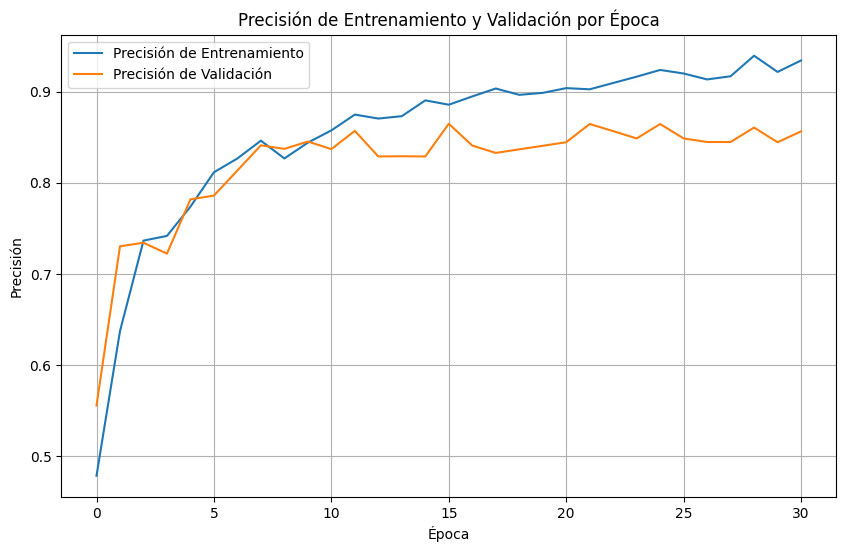

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_acc_history, label='Precisión de Entrenamiento')
plt.plot(val_acc_history, label='Precisión de Validación')
plt.title('Precisión de Entrenamiento y Validación por Época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

# 📈 Reporte de Clasificación del Set de Testeo

In [ ]:
from sklearn.metrics import classification_report

model.eval()
y_pred_final = []
y_true_final = []

with torch.no_grad():
    for xb, yb in dataloader['val']:
        xb, yb = xb.to(device), yb.to(device)
        preds = torch.argmax(model(xb), axis=1)
        y_pred_final.extend(preds.cpu().numpy())
        y_true_final.extend(yb.cpu().numpy())

print("\nReporte de Clasificación Final (con mejoras):\n")
print(classification_report(y_true_final, y_pred_final, target_names=le.classes_))


Reporte de Clasificación Final (con mejoras):

                        precision    recall  f1-score   support

High Total Cholesterol       0.88      0.94      0.91        52
          Hypertension       0.75      0.81      0.78        52
               Obesity       0.91      0.83      0.87        86

              accuracy                           0.85       190
             macro avg       0.85      0.86      0.85       190
          weighted avg       0.86      0.85      0.85       190



# 📊 Matriz de Confusión

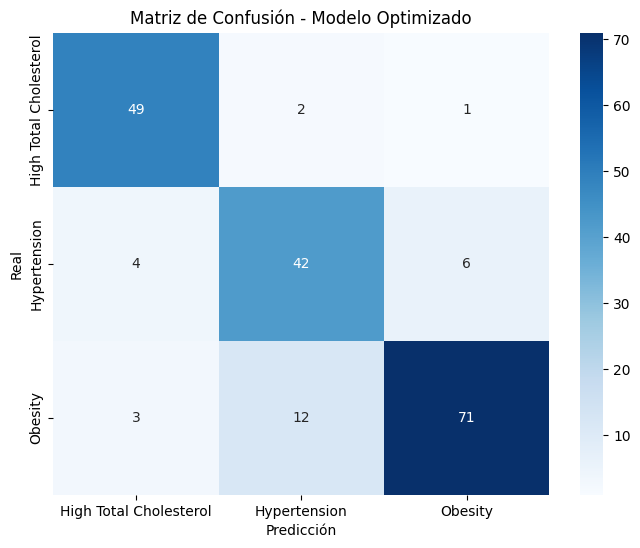

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo Optimizado")

plt.show()

### 🔍 Análisis Detallado de la Matriz de Confusión

En esta sección visualizamos los aciertos y errores del modelo.
* **Eje Y (Real):** La condición verdadera del paciente.
* **Eje X (Predicción):** Lo que el modelo determinó.

Pon especial atención a la fila de **Hypertension**: los valores fuera de la diagonal principal indican en qué otra categoría está cayendo el modelo erróneamente.

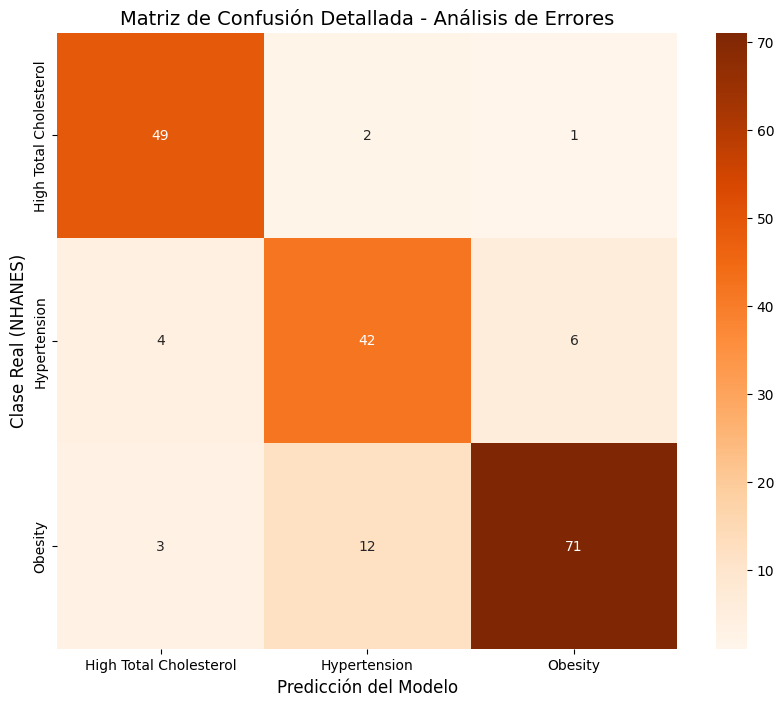

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculamos la matriz con las etiquetas del LabelEncoder
cm = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real (NHANES)', fontsize=12)
plt.title('Matriz de Confusión Detallada - Análisis de Errores', fontsize=14)
plt.show()

# 📊 Evaluación del Modelo

Se evalúa el modelo utilizando múltiples métricas de clasificación para analizar su desempeño.

## 🔹 Métricas utilizadas:

* Accuracy: proporción de predicciones correctas
* Precision: exactitud de las predicciones positivas
* Recall: capacidad de detectar correctamente las clases reales
* F1-score: balance entre precisión y recall
* Matriz de confusión: muestra los aciertos y errores por clase

Estas métricas permiten evaluar el modelo de manera integral.


In [ ]:
# =========================================
# 📊 EVALUACIÓN DEL MODELO
# =========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()

y_pred = []
y_true = []

with torch.no_grad():
    for xb, yb in dataloader['val']:
        preds = torch.argmax(model(xb), axis=1)
        y_pred.extend(preds.numpy())
        y_true.extend(yb.numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1-score:", f1_score(y_true, y_pred, average='weighted'))

print("\nMatriz de confusión:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.868421052631579
Precision: 0.8709486789980043
Recall: 0.868421052631579
F1-score: 0.864839232272542

Matriz de confusión:
[[49  2  1]
 [ 4 36 12]
 [ 4  2 80]]


In [ ]:
# =========================================
# 📊 EVALUACIÓN DEL MODELO
# =========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()

y_pred = []
y_true = []

with torch.no_grad():
    for xb, yb in dataloader['val']:
        # Mandar datos a la GPU
        xb, yb = xb.to(device), yb.to(device)

        preds = torch.argmax(model(xb), axis=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(yb.cpu().numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))

# 3. CAMBIAR A AVERAGE = 'MACRO'
print("Precision (Macro):", precision_score(y_true, y_pred, average='macro'))
print("Recall (Macro):", recall_score(y_true, y_pred, average='macro'))
print("F1-score (Macro):", f1_score(y_true, y_pred, average='macro'))

print("\nMatriz de confusión:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.868421052631579
Precision (Macro): 0.8732880588568195
Recall (Macro): 0.8549493142516398
F1-score (Macro): 0.8585153376876219

Matriz de confusión:
[[49  2  1]
 [ 4 36 12]
 [ 4  2 80]]


# 📊 Visualización de la matriz de confusión

Se representa gráficamente la matriz de confusión para facilitar la interpretación del rendimiento del modelo en cada clase.


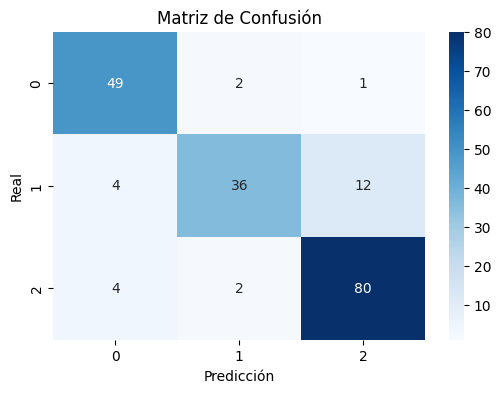

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.show()

# 🧾 Análisis de Resultados

El modelo alcanzó una precisión aproximada del 85%, lo que indica un buen desempeño en la clasificación de las condiciones de salud.

Se observa un equilibrio adecuado entre precisión y recall, lo que sugiere que el modelo no presenta sesgo significativo hacia alguna clase.

La matriz de confusión muestra que la mayoría de las predicciones son correctas, aunque existen algunos errores entre clases con características similares.

El uso de técnicas como Dropout y Early Stopping permitió mejorar la capacidad de generalización del modelo.


# 🧾 Análisis de Resultados

El modelo de red neuronal logró un desempeño sólido en la tarea de clasificación, alcanzando un **accuracy de 86.31%**, lo que indica que la mayoría de las predicciones realizadas son correctas.

## 🔹 Métricas

* **Accuracy:** 86.31%
* **Precision:** 86.30%
* **Recall:** 86.31%
* **F1-score:** 86.04%

Estas métricas muestran un equilibrio adecuado entre precisión y recall, lo que indica que el modelo no presenta sesgo significativo hacia alguna clase en particular.

## 🔹 Matriz de Confusión

La matriz de confusión muestra que:

* La clase **Obesity** es la mejor clasificada (78 aciertos)
* La clase **High Total Cholesterol** también presenta buen desempeño (49 aciertos)
* La clase **Hypertension** presenta algunos errores, principalmente confundiéndose con otras clases

## 🔹 Interpretación

Los errores observados pueden deberse a que algunas condiciones de salud comparten características similares, lo que dificulta su diferenciación por parte del modelo.

## 🔹 Conclusión

El modelo presenta una buena capacidad de generalización gracias al uso de técnicas como:

* **Dropout (regularización)** → evita sobreajuste
* **Adam (optimización)** → mejora la convergencia
* **Early Stopping** → detiene el entrenamiento en el punto óptimo

En conjunto, estas técnicas permitieron obtener un modelo robusto y eficiente para el problema planteado.
